In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

In [35]:
main_df = pd.read_csv(r"C:\Users\itsno\OneDrive\Desktop\CSULB Homework\reading-nook\git-forked-database\books.csv")
book_tags_df = pd.read_csv(r"C:\Users\itsno\OneDrive\Desktop\CSULB Homework\reading-nook\git-forked-database\book_tags.csv")
ratings_df = pd.read_csv(r"C:\Users\itsno\OneDrive\Desktop\CSULB Homework\reading-nook\git-forked-database\ratings.csv")
tags_df = pd.read_csv(r"C:\Users\itsno\OneDrive\Desktop\CSULB Homework\reading-nook\git-forked-database\tags.csv")
to_read_df = pd.read_csv(r"C:\Users\itsno\OneDrive\Desktop\CSULB Homework\reading-nook\git-forked-database\to_read.csv")

In [3]:
# Quick print to make sure all df are csv are correctly read
print(main_df.head())
print(book_tags_df.head())
print(ratings_df.head())
print(tags_df.head())
print(to_read_df.head())

   book_id  goodreads_book_id  best_book_id  work_id  books_count       isbn  \
0        1            2767052       2767052  2792775          272  439023483   
1        2                  3             3  4640799          491  439554934   
2        3              41865         41865  3212258          226  316015849   
3        4               2657          2657  3275794          487   61120081   
4        5               4671          4671   245494         1356  743273567   

         isbn13                      authors  original_publication_year  \
0  9.780439e+12              Suzanne Collins                     2008.0   
1  9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2  9.780316e+12              Stephenie Meyer                     2005.0   
3  9.780061e+12                   Harper Lee                     1960.0   
4  9.780743e+12          F. Scott Fitzgerald                     1925.0   

                             original_title  ... ratings_count  \
0 

In [4]:
# Dropping unnecessary columns in main_df
# Changing publication year from float to int
# standardizing all english (eng, en-US, en-CA, en-GB) to eng
main_df = pd.read_csv(r"C:\Users\itsno\OneDrive\Desktop\CSULB Homework\reading-nook\git-forked-database\books.csv")
main_df.head()
main_df.drop(columns=['image_url', 'small_image_url','goodreads_book_id', 'books_count', 'work_id', 'best_book_id', 'isbn', 'isbn13'], inplace=True)
main_df['original_publication_year'] = main_df['original_publication_year'].astype('Int64')

# main_df['language_code'].value_counts()

main_df['language_code'] = main_df['language_code'].str.split('-').str[0]
main_df['language_code'] = main_df['language_code'].replace({
    'en': 'eng'
})
main_df.tail()
# Note: scrolling through the csv, some strings in original_title is missing

,book_id,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
9995,9996,Ilona Andrews,2010,Bayou Moon,"Bayou Moon (The Edge, #2)",eng,4.09,17204,18856,1180,105,575,3538,7860,6778
9996,9997,Robert A. Caro,1990,Means of Ascent,"Means of Ascent (The Years of Lyndon Johnson, #2)",eng,4.25,12582,12952,395,303,551,1737,3389,6972
9997,9998,Patrick O'Brian,1977,The Mauritius Command,The Mauritius Command,eng,4.35,9421,10733,374,11,111,1191,4240,5180
9998,9999,Peggy Orenstein,2011,Cinderella Ate My Daughter: Dispatches from th...,Cinderella Ate My Daughter: Dispatches from th...,eng,3.65,11279,11994,1988,275,1002,3765,4577,2375
9999,10000,John Keegan,1998,The First World War,The First World War,NaN,4.00,9162,9700,364,117,345,2031,4138,3069


In [25]:
# ratings_df.head()
df = ratings_df.merge(main_df, on='book_id', how='left')
df = df.sort_values(by='book_id')
#df.head() #to confirm the merge happened
# df.shape #to confirm the merge happened

# will undergo further cleaning, this is a proof of concept


EDA

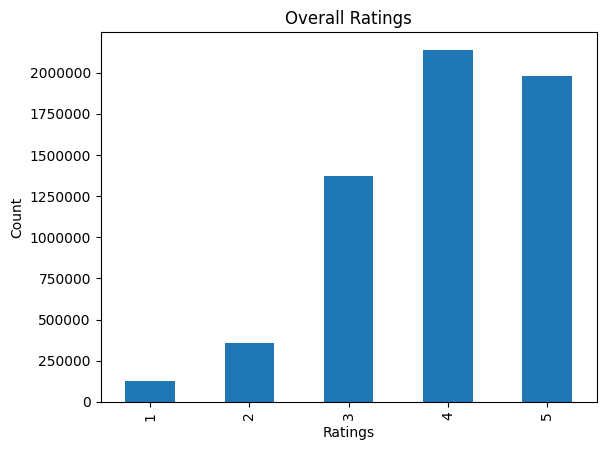

In [7]:
df['rating'].value_counts().sort_index().plot.bar(title ="Overall Ratings", xlabel = "Ratings", ylabel = "Count")
plt.ticklabel_format(style='plain', axis='y')

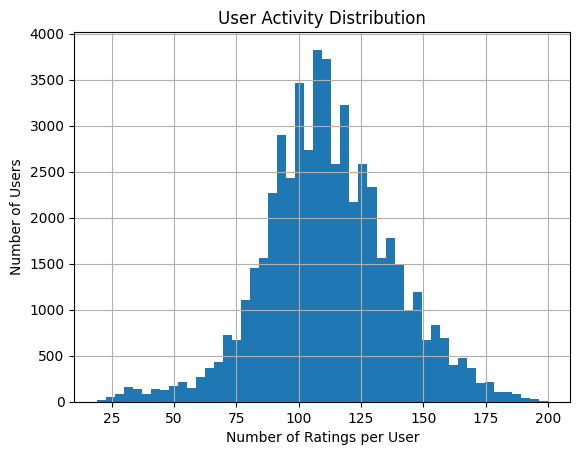

In [8]:
df['user_id'].value_counts().hist(bins=50)
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("User Activity Distribution")

plt.show()

In [9]:
df['book_id'].value_counts()
# .hist(bins=50)


book_id
1       22806
2       21850
4       19088
3       16931
5       16604
        ...  
9315       36
1935       33
9486       24
9345       11
7803        8
Name: count, Length: 10000, dtype: int64

<Axes: >

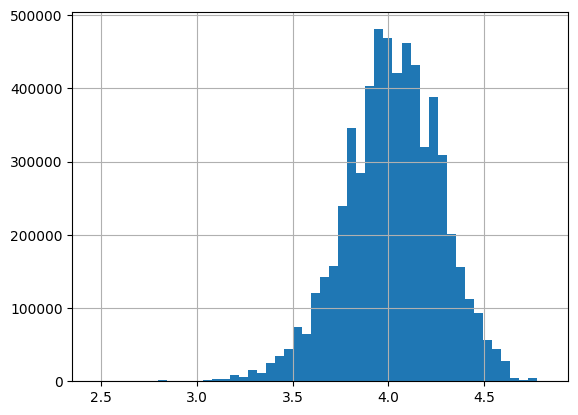

In [10]:
df['average_rating'].hist(bins=50)


<Axes: >

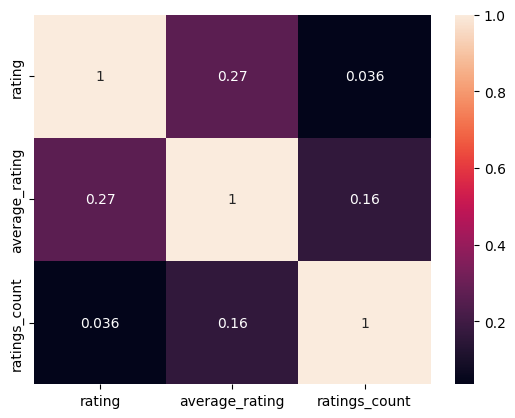

In [11]:
sns.heatmap(df[['rating', 'average_rating', 'ratings_count']].corr(), annot=True)

A little more cleaning before we get into ML models. We are going to only use active readers (they have rated at least 10 books) and then keep the books with at least 50 rating counts before applying apriori and KNN.

Remerge into df

In [61]:
book_counts = ratings_df['book_id'].value_counts()
popular_books = book_counts[book_counts >= 50].index
ratings_df = ratings_df[ratings_df['book_id'].isin(popular_books)]


# Determine active users using IQR
user_counts = ratings_df['user_id'].value_counts()
Q1 = user_counts.quantile(0.25)
Q3 = user_counts.quantile(0.75)
IQR = Q3 - Q1
threshold =  (Q1 - 1.5 * IQR)
print(threshold)


user_counts = ratings_df['user_id'].value_counts()
active_users = user_counts[user_counts >= threshold].index
ratings_df = ratings_df[ratings_df['user_id'].isin(active_users)]

df = ratings_df.merge(main_df, on='book_id', how='left')

48.0


Apriori

In [62]:
# lets recommend books if a user likes a previous book (defined as 4 or higher rating)
apriori_df = df[df['rating'] >= 4]
apriori_df = apriori_df.sort_values(by='user_id')
apriori_df.head()
apriori_df.shape

(4102563, 25)

In [63]:
# grab the top 500 most appeared books
top_books = apriori_df['book_id'].value_counts().head(500).index
apriori_df = apriori_df[apriori_df['book_id'].isin(top_books)]
book_data = pd.crosstab(apriori_df['user_id'], apriori_df['book_id'])
book_data.head(10)

book_id,1,2,3,4,5,6,7,8,9,10,...,738,739,740,757,760,792,793,806,826,840
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,1,1,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
10,0,0,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [64]:
# run for apriori and association
frequent_itemsets = apriori(book_data, min_support = 0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, num_itemsets=10, metric="confidence", min_threshold=0.5)

rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
rules = rules[(rules['support'] >= 0.1) &
              (rules['confidence'] >= 0.5) &
              (rules['lift'] >= 1)]

rules = rules[rules['consequents'].apply(lambda x: len(x) == 1)]
rules = rules[rules['antecedents'].apply(lambda x: len(x) == 1)]
rules = rules.sort_values('confidence', ascending=[False])
rules

c:\Users\itsno\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,support,confidence,lift
35,frozenset({23}),frozenset({18}),0.210384,0.891529,3.405792
61,frozenset({27}),frozenset({25}),0.223507,0.884644,3.389370
36,frozenset({24}),frozenset({18}),0.227131,0.877265,3.351302
31,frozenset({20}),frozenset({17}),0.175917,0.876461,3.543422
59,frozenset({27}),frozenset({24}),0.220741,0.873698,3.374556
...,...,...,...,...,...
14,frozenset({2}),frozenset({23}),0.181868,0.524939,2.224501
0,frozenset({1}),frozenset({2}),0.188563,0.524846,1.514899
25,frozenset({10}),frozenset({4}),0.104696,0.524260,1.718513
12,frozenset({2}),frozenset({21}),0.179770,0.518884,2.111294


In [65]:
book_map = dict(zip(df['book_id'], df['title']))

def convert_frozenset(fs):
    return [book_map.get(i, i) for i in fs]

rules['antecedents_titles'] = rules['antecedents'].apply(convert_frozenset)
rules['consequents_titles'] = rules['consequents'].apply(convert_frozenset)

In [66]:
pd.set_option('display.max_colwidth', None)
rules[['antecedents_titles', 'consequents_titles', 'support', 'confidence', 'lift']].head()

,antecedents_titles,consequents_titles,support,confidence,lift
35,"[Harry Potter and the Chamber of Secrets (Harry Potter, #2)]","[Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)]",0.210384,0.891529,3.405792
61,"[Harry Potter and the Half-Blood Prince (Harry Potter, #6)]","[Harry Potter and the Deathly Hallows (Harry Potter, #7)]",0.223507,0.884644,3.389370
36,"[Harry Potter and the Goblet of Fire (Harry Potter, #4)]","[Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)]",0.227131,0.877265,3.351302
31,"[Mockingjay (The Hunger Games, #3)]","[Catching Fire (The Hunger Games, #2)]",0.175917,0.876461,3.543422
59,"[Harry Potter and the Half-Blood Prince (Harry Potter, #6)]","[Harry Potter and the Goblet of Fire (Harry Potter, #4)]",0.220741,0.873698,3.374556


KNN